In [16]:
import matplotlib.pyplot as plt
from gen_catalyst_design.db import Database, load_datadicts_from_db
import numpy as np
from ase.io import write

In [17]:
db = Database.establish_connection(
    "result_42_seed.db"
)
datadicts = load_datadicts_from_db(database=db)
rates = np.array([datadict["rate"] for datadict in datadicts])
e_forms = np.array([datadict["e_form"] for datadict in datadicts])

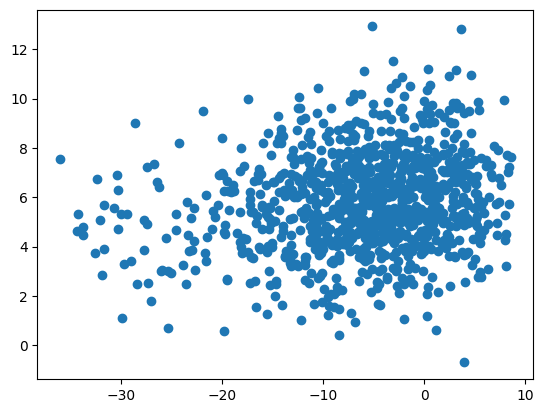

In [18]:
fig, ax = plt.subplots()

ax.scatter(np.log(rates), e_forms)


In [19]:
template_atoms = db.template_atoms_surf
atoms_list = []
for datadict in datadicts:
    atoms = template_atoms.copy()
    atoms.symbols = datadict["elements"]
    atoms.info["rate"] = datadict["rate"]
    atoms.info["e_form"] = datadict["e_form"]
    atoms_list.append(atoms)

write("rnd_rate_eform.traj", atoms_list)

In [20]:
print(np.max(rates), np.min(rates))
print(np.max(e_forms), np.min(e_forms))

5230.32692485898 2.1080127548775946e-16
12.920029 -0.69207764


In [21]:
np.exp(9)

np.float64(8103.083927575384)

In [15]:
np.max(rates)*0.9

np.float64(4707.294232373082)